# Project


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalTemperatures.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByState.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCountry.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByMajorCity.csv


# Load CSV

In [2]:
# Base path for the datasets
base_path = '/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/'
global_path = base_path + 'GlobalTemperatures.csv'
country_path = base_path + 'GlobalLandTemperaturesByCountry.csv'
#city_path = base_path + 'GlobalLandTemperaturesByMajorCity.csv'

# Loading the data
df_global = pd.read_csv(global_path)
df_country = pd.read_csv(country_path)

# Data Cleaning (global_path)

In [3]:
# Check if the table was loaded successfully
df_global.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
def clean_climate_data(df, start_year=1850):
    # 1. המרת עמודת התאריך לפורמט datetime
    df['dt'] = pd.to_datetime(df['dt'])
    
    # 2. הסרת שורות שבהן הטמפרטורה חסרה (NaN)
    # שים לב: השם המדויק בנתונים שלך הוא LandAverageTemperature
    df = df.dropna(subset=['LandAverageTemperature'])
    
    # 3. סינון נתונים - החל מ-1850 (שימוש ב-copy כדי למנוע שגיאות זיכרון)
    df = df[df['dt'].dt.year >= start_year].copy()
    
    # 4. הוספת עמודות שנה וחודש לנוחות הניתוח
    df['year'] = df['dt'].dt.year
    df['month'] = df['dt'].dt.month
    
    # שינוי שם העמודה לשם גנרי ונוח יותר (אופציונלי)
    df = df.rename(columns={'LandAverageTemperature': 'AverageTemperature'})

    return df

# החלת הניקוי על ה-DataFrame שלך
df_global = clean_climate_data(df_global)

# בדיקה שהנתונים נקיים
print(f"Number of rows after cleaning: {len(df_global)}")
print("\nFirst 5 rows of cleaned data:")
print(df_global.head())

Number of rows after cleaning: 1992

First 5 rows of cleaned data:
             dt  AverageTemperature  LandAverageTemperatureUncertainty  \
1200 1850-01-01               0.749                              1.105   
1201 1850-02-01               3.071                              1.275   
1202 1850-03-01               4.954                              0.955   
1203 1850-04-01               7.217                              0.665   
1204 1850-05-01              10.004                              0.617   

      LandMaxTemperature  LandMaxTemperatureUncertainty  LandMinTemperature  \
1200               8.242                          1.738              -3.206   
1201               9.970                          3.007              -2.291   
1202              10.347                          2.401              -1.905   
1203              12.934                          1.004               1.018   
1204              15.655                          2.406               3.811   

      LandMin

# Data Cleaning (country_path)

In [5]:
# Check if the table was loaded successfully
df_country.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [6]:
def clean_climate_data(df, start_year=1850):
    # 1. Convert the date column to datetime format
    df['dt'] = pd.to_datetime(df['dt'])
    
    # 2. Remove rows where the temperature is NaN
    df = df.dropna(subset=['AverageTemperature'])
    
    # 3. Filter data - start from 1850 to ensure reliability
    df = df[df['dt'].dt.year >= 1850]
    
    # 4. Add year and month columns for convenience of analysis
    df['year'] = df['dt'].dt.year
    df['month'] = df['dt'].dt.month

    return df

# Apply cleaning
df_country = clean_climate_data(df_country)
# Check that the data is clean
print(f"Number of rows after cleaning: {len(df_country)}")
df_country.head()

Number of rows after cleaning: 452458


,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year,month
1274,1850-01-01,-9.083,1.834,Åland,1850,1
1275,1850-02-01,-2.309,1.603,Åland,1850,2
1276,1850-03-01,-4.801,3.033,Åland,1850,3
1277,1850-04-01,1.242,2.008,Åland,1850,4
1278,1850-05-01,7.920,0.881,Åland,1850,5


# First visualiztion (df_global)

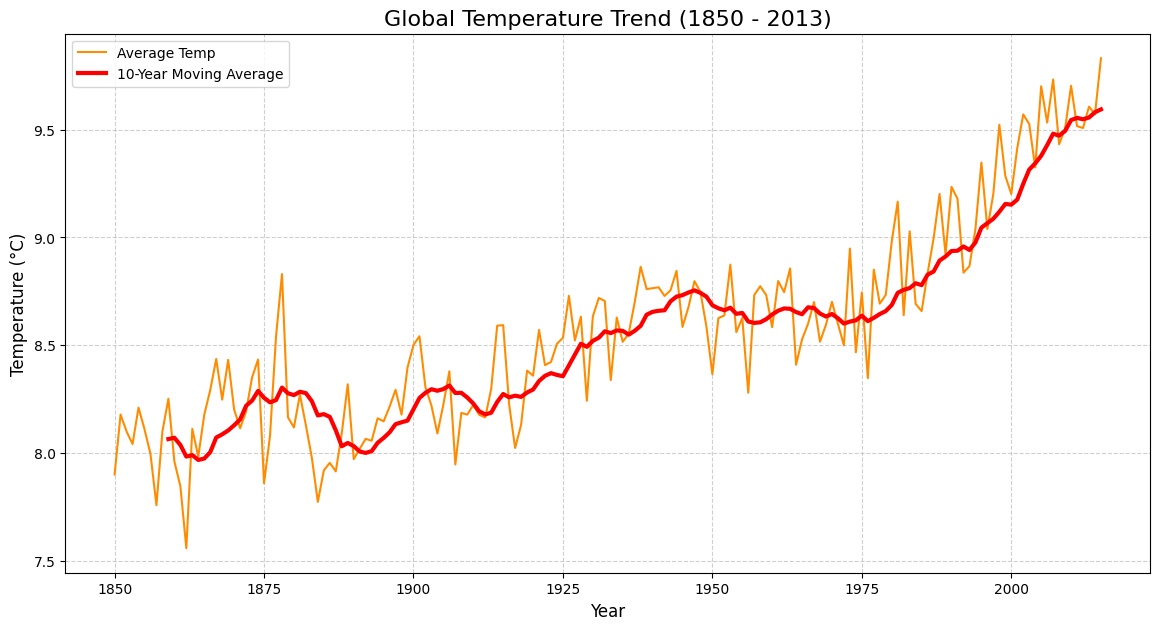

In [7]:
# Calculate global annual average
global_monthly_avg = df_global.groupby('year')['AverageTemperature'].mean()

# Creating the plot
plt.figure(figsize=(14, 7))
plt.plot(global_monthly_avg.index, global_monthly_avg.values, label='Average Temp', color='darkorange')

# Adding a "10-year moving average" to smooth the graph and see a clear trend
plt.plot(global_monthly_avg.rolling(window=10).mean(), label='10-Year Moving Average', color='red', linewidth=3)

plt.title('Global Temperature Trend (1850 - 2013)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Research Question 1 (df_global)
Statistical Analysis (Research Question Question 1)

We will split the data into two periods:

Period 1: 1954 - 1983

Period 2: 1984 - 2013

We will calculate the average annual temperature for each year and then use Linear Regression to find the slope (rate of warming) for each period.

In [8]:
from scipy import stats

# 1. Prepare global annual averages
annual_temp = df_global.groupby('year')['AverageTemperature'].mean().reset_index()

# 2. Define the two 30-year periods
period1 = annual_temp[(annual_temp['year'] >= 1954) & (annual_temp['year'] <= 1983)]
period2 = annual_temp[(annual_temp['year'] >= 1984) & (annual_temp['year'] <= 2013)]

# 3. Calculate Linear Regression for Period 1
slope1, intercept1, r_value1, p_value1, std_err1 = stats.linregress(period1['year'], period1['AverageTemperature'])

# 4. Calculate Linear Regression for Period 2
slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress(period2['year'], period2['AverageTemperature'])

print(f"Warming Rate 1954-1983 (Slope): {slope1:.4f} °C per year")
print(f"Warming Rate 1984-2013 (Slope): {slope2:.4f} °C per year")

# 5. Calculate the acceleration factor
acceleration = slope2 / slope1
print(f"The warming rate in the last 30 years is {acceleration:.2f} times faster than the previous period.")

Warming Rate 1954-1983 (Slope): 0.0085 °C per year
Warming Rate 1984-2013 (Slope): 0.0304 °C per year
The warming rate in the last 30 years is 3.56 times faster than the previous period.


# Research Question 2 (Global)
Research Question 2: Is there an increase in the frequency and intensity of extreme temperature events in the last decade?

### Methodology:
To identify "extreme events," we first define a **Baseline Period (1951-1980)**. 
1. We calculate the Mean ($\mu$) and Standard Deviation ($\sigma$) of the global temperature during this baseline.
2. An "Extreme Event" is defined as any month where the temperature is **> 2 Standard Deviations** above the baseline mean ($Temp > \mu + 2\sigma$).
3. We then compare the number of these events across different decades.

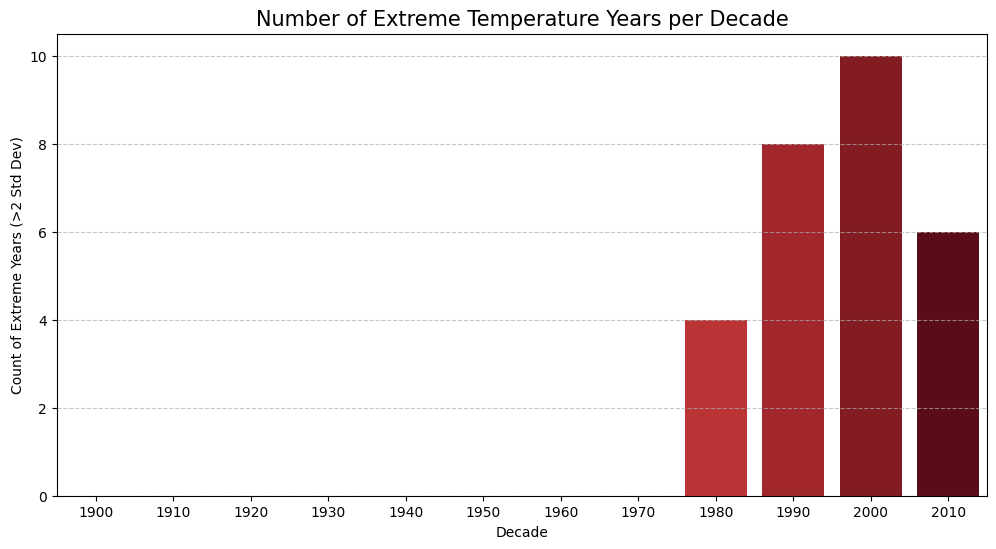

The baseline mean was 8.66°C with a Std Dev of 0.17°C.
Any year above 8.99°C is considered an extreme event.


In [9]:
# 1. Define Baseline (1951-1980)
baseline = annual_temp[(annual_temp['year'] >= 1951) & (annual_temp['year'] <= 1980)]
baseline_mean = baseline['AverageTemperature'].mean()
baseline_std = baseline['AverageTemperature'].std()

# Define the threshold for an "Extreme Event" (2 Standard Deviations)
threshold = baseline_mean + (2 * baseline_std)

# 2. Identify extremes in the entire dataset
annual_temp['is_extreme'] = annual_temp['AverageTemperature'] > threshold

# 3. Group by Decade to see the trend
annual_temp['decade'] = (annual_temp['year'] // 10) * 10
extreme_counts = annual_temp.groupby('decade')['is_extreme'].sum().reset_index()

# 4. Visualization
plt.figure(figsize=(12, 6))
#sns.barplot(data=extreme_counts[extreme_counts['decade'] >= 1900], x='decade', y='is_extreme', palette='Reds')
sns.barplot(
    data=extreme_counts[extreme_counts['decade'] >= 1900], 
    x='decade', 
    y='is_extreme', 
    hue='decade', 
    palette='Reds', 
    legend=False
)

plt.title('Number of Extreme Temperature Years per Decade', fontsize=15)
plt.xlabel('Decade')
plt.ylabel('Count of Extreme Years (>2 Std Dev)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"The baseline mean was {baseline_mean:.2f}°C with a Std Dev of {baseline_std:.2f}°C.")
print(f"Any year above {threshold:.2f}°C is considered an extreme event.")

# Research Question 3 (df_country)
Research Question 3: Which region has experienced the most drastic change in temperature?

### Methodology:
We will group the data by Country and compare the average temperature from the **19th Century (1850-1899)** to the **21st Century (2000-2013)**. 
This allows us to identify which areas are "warming hotspots."

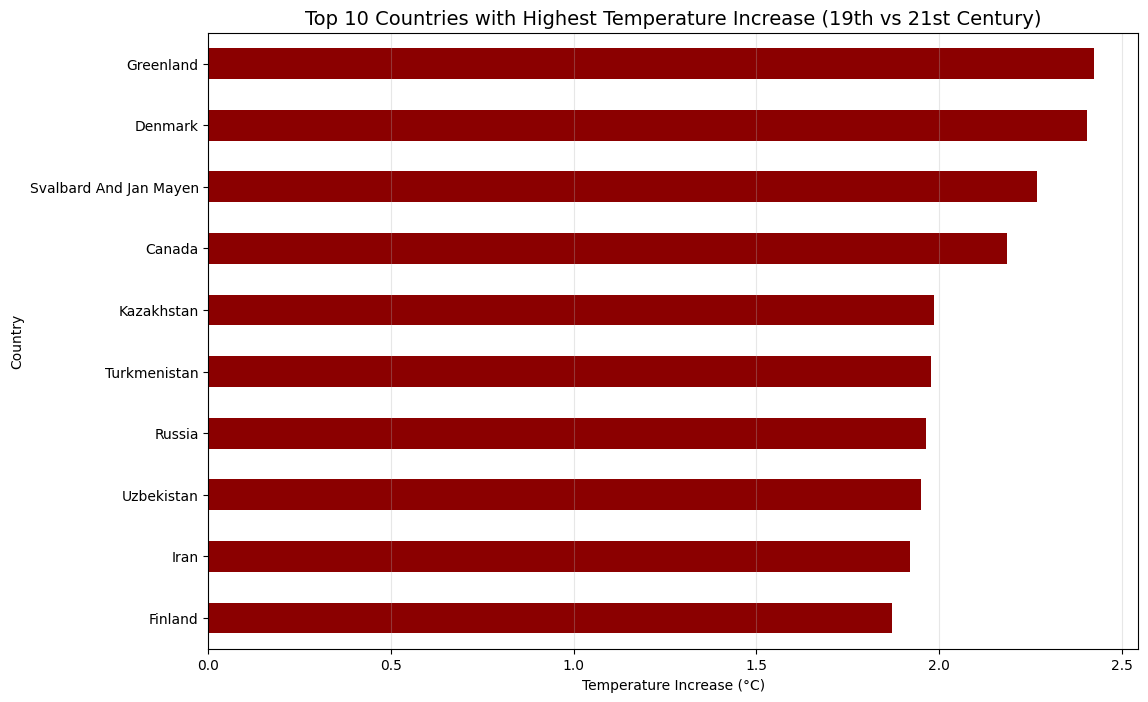

In [10]:
# 1. Calculate average temp per country for two eras
past_era = df_country[df_country['year'] <= 1899].groupby('Country')['AverageTemperature'].mean()
modern_era = df_country[df_country['year'] >= 2000].groupby('Country')['AverageTemperature'].mean()

# 2. Calculate the difference (Warming Amount)
warming_diff = (modern_era - past_era).dropna().sort_values(ascending=False)

# 3. Visualize Top 10 Countries with highest warming
plt.figure(figsize=(12, 8))
warming_diff.head(10).plot(kind='barh', color='darkred')

plt.title('Top 10 Countries with Highest Temperature Increase (19th vs 21st Century)', fontsize=14)
plt.xlabel('Temperature Increase (°C)')
plt.ylabel('Country')
plt.gca().invert_yaxis() # Highest on top
plt.grid(axis='x', alpha=0.3)
plt.show()

## Visual Map

In [11]:
import plotly.express as px
import pandas as pd

# 1. הכנת הנתונים (נניח שזה ה-df שלך)
# נבצע המרה של עמודת התאריך
df_country['dt'] = pd.to_datetime(df_country['dt'])
df_country['Year'] = df_country['dt'].dt.year

# 2. ניקוי ערכים חסרים וחישוב ממוצע שנתי לכל מדינה
# זה יהפוך את המפה להרבה יותר חלקה וברורה
df_yearly = df_country.dropna(subset=['AverageTemperature']).groupby(['Country', 'Year'])['AverageTemperature'].mean().reset_index()

# 3. יצירת מפת כורופלת (Choropleth) עם ציר זמן
fig = px.choropleth(
    df_yearly, 
    locations="Country", 
    locationmode='country names', # מזהה מדינות לפי השם שלהן (כמו Åland, Israel וכו')
    color="AverageTemperature", 
    hover_name="Country",
    animation_frame="Year",      # יוצר את סרגל הזמן למטה
    color_continuous_scale=px.colors.sequential.YlOrRd, # סקאלת צבעים מצהוב לאדום
    title="שינויי טמפרטורה ממוצעת לאורך השנים",
    labels={'AverageTemperature': 'טמפ׳ ממוצעת (°C)'}
)

# 4. התאמות לתצוגה ב-Kaggle
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show(renderer="iframe")

In [12]:
import plotly.express as px

# 1. עיבוד מקדים (בהנחה שכבר הרצת את המרת התאריכים מהשלב הקודם)
# חישוב ממוצע שנתי כדי שהגרף יהיה קריא ונקי
df_trend = df_country.dropna(subset=['AverageTemperature']).copy()
df_trend['Year'] = pd.to_datetime(df_trend['dt']).dt.year
df_yearly_trend = df_trend.groupby(['Country', 'Year'])['AverageTemperature'].mean().reset_index()

# 2. בחירת מדינות להשוואה (אופציונלי - כדי שהגרף לא יהיה עמוס מדי)
# נבחר למשל 5 מדינות מעניינות או את כולן
selected_countries = ['Israel', 'Norway', 'Brazil', 'Canada', 'Spain']
df_filtered = df_yearly_trend[df_yearly_trend['Country'].isin(selected_countries)]

# 3. יצירת הגרף הקווי
fig_line = px.line(
    df_filtered, 
    x="Year", 
    y="AverageTemperature", 
    color="Country",      # כל מדינה קו בצבע שונה
    markers=True,         # נקודות על כל שנה
    title="מגמת שינוי טמפרטורה שנתית ממוצעת",
    labels={"AverageTemperature": "טמפרטורה (C°)", "Year": "שנה"}
)

# 4. שיפור הוויזואליות (כמו שביקשת)
fig_line.update_layout(
    hovermode="x unified", # מציג את כל המדינות יחד בציפה מעל השנה
    legend_title_text='מדינה',
    xaxis_title="שנה",
    yaxis_title="טמפרטורה ממוצעת"
)

# הצגה ב-Kaggle
fig_line.show(renderer="iframe")

# Test and other

## בדיקת טווח שנים וחוסרים (1750 - 2015)

In [ ]:
import pandas as pd

# טעינת הדאטה-סט
df = pd.read_csv('/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalTemperatures.csv')

# המרה לפורמט תאריך (חשוב!)
df['dt'] = pd.to_datetime(df['dt'])

# בדיקת השנה המוקדמת והמאוחרת ביותר
print(f"התאריך המוקדם ביותר: {df['dt'].min()}")
print(f"התאריך המאוחר ביותר: {df['dt'].max()}")

year_min = df['dt'].dt.year.min()
year_max = df['dt'].dt.year.max()
total_years = df['dt'].dt.year.nunique()

print(f"הנתונים מתחילים בשנת: {year_min}")
print(f"הנתונים מסתיימים בשנת: {year_max}")
print(f"סה''כ שנים ייחודיות בדאטה: {total_years}")

# בדיקה האם יש חוסרים (למשל אם הטווח הוא 100 שנה אבל יש רק 80 שנים של דאטה)
expected_years = year_max - year_min + 1
if total_years == expected_years:
    print("✅ אין שנים חסרות בטווח!")
else:
    print(f"⚠️ שים לב: חסרות {expected_years - total_years} שנים בטווח הזה.")

In [ ]:
sns.boxplot(x=df['LandAverageTemperature'])

In [ ]:
# בדיקה כמה חודשים יש לכל שנה
counts = df.groupby('Year').size()
print(counts[counts != 12]) # יציג שנים שאין בהן 12 חודשים